# Parameter Sensitivity in VISTA

Every MCDA method has tunable parameters — thresholds, coefficients, preference functions — that shape its behavior. This notebook demonstrates how to use VISTA maps to **visually explore** the effect of parameter changes. By sweeping a single parameter while holding everything else fixed, we can see exactly which regions of the criterion space are affected and how.

In [1]:
%matplotlib inline

from mcda_vista import generate_vista, plot_vista, plot_vista_grid, plot_vista_comparison, VistaResult
from mcda_vista.methods import get_method

## Indifference Threshold δ in TOPSIS

TOPSIS computes a closeness coefficient for each alternative. The **δ** (delta) parameter defines how close two coefficients must be for the method to declare them *indifferent*. When δ = 0 there is no indifference zone — every pair is ordered. As δ grows, the yellow (indifferent) region expands around the boundary between *better* and *worse*.

VISTA (topsis):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (topsis):  87%|████████▋ | 2263/2601 [00:00<00:00, 22514.13pt/s]

VISTA (topsis): 100%|██████████| 2601/2601 [00:00<00:00, 22322.91pt/s]

VISTA (topsis):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (topsis):  87%|████████▋ | 2261/2601 [00:00<00:00, 22468.97pt/s]

...

VISTA (topsis):  41%|████      | 1070/2601 [00:00<00:00, 5328.05pt/s]

VISTA (topsis):  63%|██████▎   | 1635/2601 [00:00<00:00, 5460.24pt/s]

VISTA (topsis):  84%|████████▍ | 2182/2601 [00:00<00:00, 5386.06pt/s]

VISTA (topsis): 100%|██████████| 2601/2601 [00:00<00:00, 5371.16pt/s]

C:\Users\dariu\AppData\Local\Temp\ipykernel_30548\406932928.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


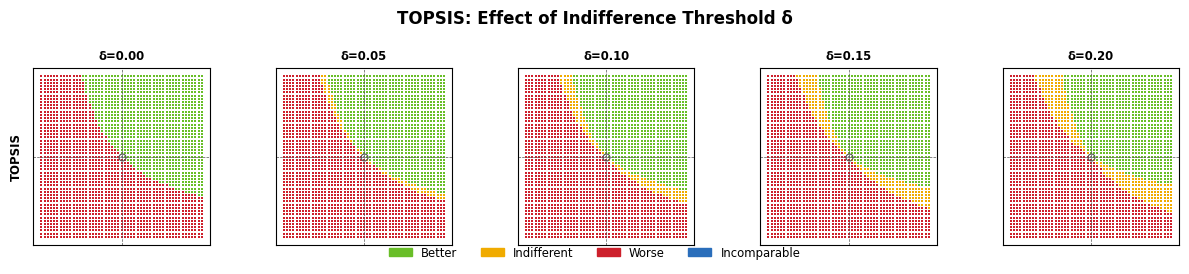

In [2]:
delta_values = [0.00, 0.05, 0.10, 0.15, 0.20]

topsis_results = [
    generate_vista("topsis", resolution=51, delta=d)
    for d in delta_values
]

fig = plot_vista_grid(
    [topsis_results],
    row_labels=["TOPSIS"],
    col_labels=[f"δ={d:.2f}" for d in delta_values],
    title="TOPSIS: Effect of Indifference Threshold δ",
)
fig.show()

**Observations:**

- At **δ = 0.00** the map contains only green (better) and red (worse) — no indifference zone at all.
- As δ increases, a yellow band appears and widens along the boundary, indicating that more and more pairs of alternatives are considered indistinguishable.
- This is a key modeling choice: a larger δ makes the method more conservative about declaring one alternative superior to another.

## Strategy Coefficient *v* in VIKOR

VIKOR ranks alternatives by a compromise measure that blends two terms:

- **S** — *group utility* (the weighted sum of criterion-level regrets),
- **R** — *individual regret* (the worst single-criterion regret).

The parameter **v ∈ [0, 1]** controls the balance:

- *v* = 0 → only individual regret matters,
- *v* = 1 → only group utility matters,
- *v* = 0.5 → balanced compromise (default).

VISTA (vikor):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (vikor):  10%|█         | 265/2601 [00:00<00:00, 2629.02pt/s]

VISTA (vikor):  20%|██        | 533/2601 [00:00<00:00, 2651.16pt/s]

VISTA (vikor):  31%|███       | 799/2601 [00:00<00:00, 2407.85pt/s]

VISTA (vikor):  40%|████      | 1043/2601 [00:00<00:00, 2407.56pt/s]

...

VISTA (vikor):  70%|███████   | 1825/2601 [00:00<00:00, 2355.04pt/s]

VISTA (vikor):  80%|████████  | 2089/2601 [00:00<00:00, 2434.06pt/s]

VISTA (vikor):  91%|█████████ | 2355/2601 [00:00<00:00, 2497.11pt/s]

VISTA (vikor): 100%|██████████| 2601/2601 [00:01<00:00, 2483.96pt/s]

C:\Users\dariu\AppData\Local\Temp\ipykernel_30548\2077097126.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


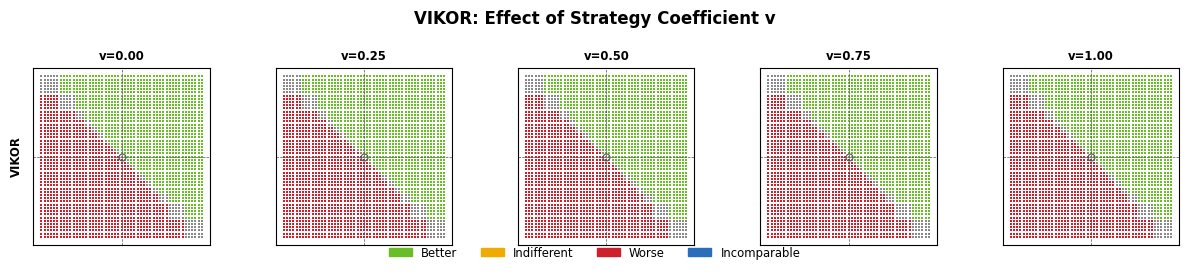

In [3]:
v_values = [0.00, 0.25, 0.50, 0.75, 1.00]

vikor_results = [
    generate_vista("vikor", resolution=51, v=v)
    for v in v_values
]

fig = plot_vista_grid(
    [vikor_results],
    row_labels=["VIKOR"],
    col_labels=[f"v={v:.2f}" for v in v_values],
    title="VIKOR: Effect of Strategy Coefficient v",
)
fig.show()

**Observations:**

- At **v = 0** the ranking depends solely on individual regret, producing a map where the boundary follows the *worst* criterion.
- At **v = 1** the ranking depends solely on group utility, producing a smoother, more diagonal boundary.
- Intermediate values blend both criteria, smoothly interpolating the boundary shape between the two extremes.

## Thresholds in ELECTRE III

ELECTRE III uses three thresholds per criterion:

- **q** — *indifference* threshold: differences below *q* are ignored,
- **p** — *preference* threshold: differences above *p* yield full preference,
- **v** — *veto* threshold: differences above *v* block outranking entirely.

Below we fix the veto threshold (v = 1.0), cut-level slope (α = −0.15) and intercept (β = 0.30), and sweep **q** and **p** over a 3 × 3 grid.

VISTA (electre_iii):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (electre_iii):   6%|▌         | 144/2601 [00:00<00:01, 1437.48pt/s]

VISTA (electre_iii):  11%|█         | 288/2601 [00:00<00:01, 1416.05pt/s]

VISTA (electre_iii):  17%|█▋        | 436/2601 [00:00<00:01, 1440.13pt/s]

VISTA (electre_iii):  23%|██▎       | 596/2601 [00:00<00:01, 1498.78pt/s]

...

VISTA (electre_iii):  85%|████████▍ | 2198/2601 [00:01<00:00, 1449.16pt/s]

VISTA (electre_iii):  91%|█████████ | 2357/2601 [00:01<00:00, 1487.78pt/s]

VISTA (electre_iii):  97%|█████████▋| 2527/2601 [00:01<00:00, 1546.37pt/s]

VISTA (electre_iii): 100%|██████████| 2601/2601 [00:01<00:00, 1426.88pt/s]

C:\Users\dariu\AppData\Local\Temp\ipykernel_30548\2886408838.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


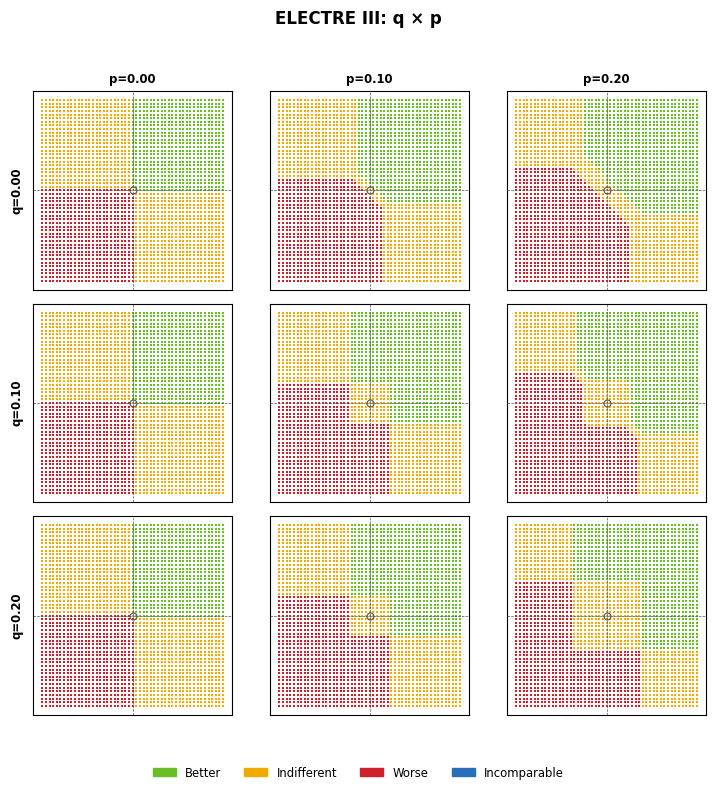

In [4]:
q_values = [0.00, 0.10, 0.20]
p_values = [0.00, 0.10, 0.20]

electre_base = dict(v=1.0, alpha=-0.15, beta=0.30)

electre_grid = [
    [
        generate_vista(
            "electre_iii", resolution=51,
            q=q, p=p, **electre_base,
        )
        for p in p_values
    ]
    for q in q_values
]

fig = plot_vista_grid(
    electre_grid,
    row_labels=[f"q={q:.2f}" for q in q_values],
    col_labels=[f"p={p:.2f}" for p in p_values],
    title="ELECTRE III: q × p",
)
fig.show()

**Observations:**

- **q = 0, p = 0** is the strictest setting — tiny differences lead to preference — so the map looks most like a crisp ranking.
- Increasing **q** expands the indifference zone (yellow), because the method tolerates larger performance gaps before deciding.
- Increasing **p** broadens the transition between indifference and strict preference, which can increase the incomparable (blue) region.
- The interplay between q and p shapes the overall sensitivity of ELECTRE III to small differences in criteria values.

## Preference Functions in PROMETHEE I

PROMETHEE allows the user to choose a **preference function** that maps criterion-level differences to a degree of preference ∈ [0, 1]. The library supports seven types:

| Type | Name | Key feature |
|------|------|-------------|
| t1 | Usual | 0/1 step — any positive difference gives full preference |
| t2 | U-shape | q-threshold step — differences below *q* are ignored |
| t3 | V-shape | Linear increase from 0 to *p* |
| t4 | Level | Two-step: *q* → 0.5, *p* → 1.0 |
| t5 | V-shape with indifference | Linear between *q* and *p* |
| t6 | Gaussian | Smooth Gaussian curve controlled by *s* |

Below we generate a VISTA map for each type (t1 through t6), fixing q = 0.10, p = 0.20, s = 0.15.

VISTA (promethee_i):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (promethee_i):  31%|███       | 807/2601 [00:00<00:00, 8011.67pt/s]

VISTA (promethee_i):  62%|██████▏   | 1609/2601 [00:00<00:00, 8006.88pt/s]

VISTA (promethee_i):  93%|█████████▎| 2410/2601 [00:00<00:00, 7844.39pt/s]

VISTA (promethee_i): 100%|██████████| 2601/2601 [00:00<00:00, 7809.25pt/s]

...

VISTA (promethee_i):  31%|███       | 800/2601 [00:00<00:00, 7956.40pt/s]

VISTA (promethee_i):  61%|██████▏   | 1596/2601 [00:00<00:00, 7624.96pt/s]

VISTA (promethee_i):  91%|█████████ | 2360/2601 [00:00<00:00, 7381.72pt/s]

VISTA (promethee_i): 100%|██████████| 2601/2601 [00:00<00:00, 7388.85pt/s]

C:\Users\dariu\AppData\Local\Temp\ipykernel_30548\928056495.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


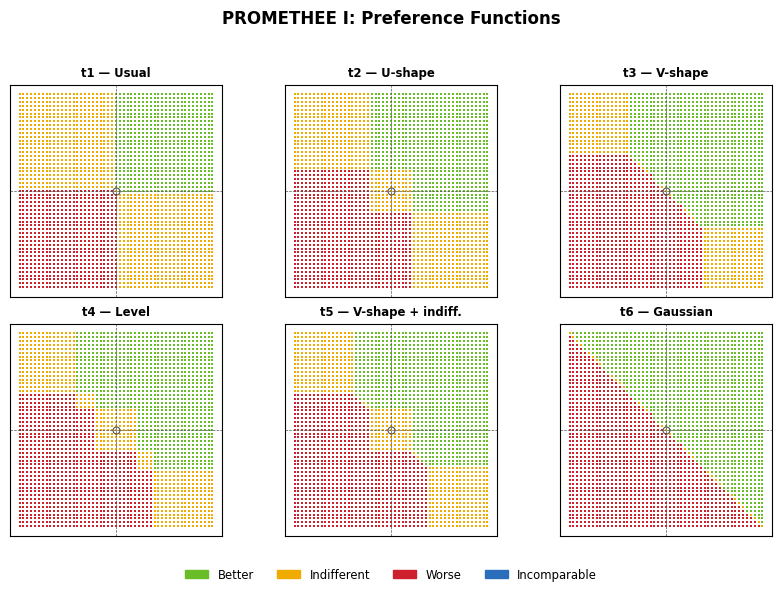

In [5]:
f_types = ["t1", "t2", "t3", "t4", "t5", "t6"]
f_labels = ["Usual", "U-shape", "V-shape", "Level", "V-shape + indiff.", "Gaussian"]

promethee_results = []
for ft, label in zip(f_types, f_labels):
    r = generate_vista(
        "promethee_i", resolution=51,
        f=ft, q=0.10, p=0.20, s=0.15,
    )
    # Override method_name for clearer subplot titles
    r = VistaResult(
        grid=r.grid, relations=r.relations, reference=r.reference,
        weights=r.weights, method_name=f"{ft} — {label}",
        params=r.params, resolution=r.resolution, n_criteria=r.n_criteria,
        third_alternative=r.third_alternative,
        extra_alternatives=r.extra_alternatives,
        metadata=r.metadata,
    )
    promethee_results.append(r)

fig = plot_vista_comparison(promethee_results, ncols=3, title="PROMETHEE I: Preference Functions")
fig.show()

**Observations:**

- **t1 (Usual)** is the simplest — any positive difference yields preference, so the boundary is sharp.
- **t2 (U-shape)** adds an indifference zone below *q*, widening the yellow region.
- **t3 (V-shape)** introduces a gradual increase in preference up to *p*, smoothing the boundary.
- **t4 (Level)** is a two-step function — halfway preference between *q* and *p*, full above *p*.
- **t5 (V-shape with indifference)** combines a dead zone below *q* with a linear ramp to *p*.
- **t6 (Gaussian)** yields the smoothest transition, controlled by the standard deviation *s*.

Different preference functions model different assumptions about how criterion-level differences translate into degrees of preference. The VISTA maps make these differences visible at a glance.

## Reading Parameter Metadata

Every method adapter exposes a `param_space()` method that describes the name, range, default, and step size for each tunable parameter. This metadata drives the sensitivity sweeps above and also powers the interactive dashboard sliders.

In [6]:
for name in ["topsis", "vikor", "electre_iii", "promethee_i"]:
    adapter = get_method(name)
    print(f"\n{adapter.display_name}")
    print("-" * 40)
    for pname, meta in adapter.param_space().items():
        if "choices" in meta:
            print(f"  {pname:10s}  choices={meta['choices']}  "
                  f"default={meta['default']}  "
                  f"label={meta['label']!r}")
        else:
            print(f"  {pname:10s}  range=[{meta['min']}, {meta['max']}]  "
                  f"default={meta['default']}  step={meta['step']}  "
                  f"label={meta['label']!r}")


TOPSIS
----------------------------------------
  delta       range=[0.0, 0.5]  default=0.1  step=0.05  label='δ (indifference threshold)'

VIKOR
----------------------------------------
  v           range=[0.0, 1.0]  default=0.5  step=0.25  label='v (strategy coefficient)'

ELECTRE III
----------------------------------------
  q           range=[0.0, 0.5]  default=0.1  step=0.05  label='q (indifference)'
  p           range=[0.0, 1.0]  default=0.2  step=0.05  label='p (preference)'
  v           range=[0.1, 2.0]  default=1.0  step=0.1  label='v (veto)'
  alpha       range=[-0.5, 0.0]  default=-0.15  step=0.05  label='α (cut-level slope)'
  beta        range=[0.0, 1.0]  default=0.3  step=0.05  label='β (cut-level intercept)'

PROMETHEE I
----------------------------------------
  f           choices=['t1', 't2', 't3', 't4', 't5', 't6', 't7']  default=t4  label='Preference function type'
  q           range=[0.0, 0.5]  default=0.1  step=0.05  label='q (indifference)'
  p           ra

The `VistaResult` object also stores the exact parameters used in a run, along with timing information:

In [7]:
# Pick one of the TOPSIS results from the earlier sweep
sample = topsis_results[2]  # delta=0.10

print("Method:          ", sample.method_name)
print("Parameters:      ", sample.params)
print("Elapsed seconds: ", sample.metadata.get("elapsed_seconds", "N/A"))

Method:           topsis
Parameters:       {'delta': 0.1}
Elapsed seconds:  0.197791699989466


## Summary

Key takeaways from this notebook:

1. **Small parameter changes can have large visual effects.** VISTA maps make these effects immediately apparent — something that is hard to detect from ranking tables alone.

2. **Indifference thresholds (δ, q)** control how much of the criterion space is classified as *indifferent*. Setting them to zero removes the indifference zone entirely; increasing them makes the method more tolerant.

3. **Strategy / weighting coefficients (v in VIKOR)** shift the balance between competing objectives within the method, reshaping the boundary between *better* and *worse* regions.

4. **Multi-parameter interactions (q × p in ELECTRE III)** are best explored with a grid layout — `plot_vista_grid` is designed exactly for this.

5. **Preference functions (PROMETHEE)** encode fundamentally different assumptions about how criterion differences translate into preference degrees, producing visibly distinct VISTA maps.

6. **Parameter metadata** is available programmatically via `adapter.param_space()`, making it easy to automate sweeps and build interactive dashboards.

In the next notebooks we will build on these ideas to compare methods head-to-head and explore higher-dimensional criterion spaces.